# Ensayo inicial y búsqueda de la estación más cercana

Esta hoja serivrá para ofrecer como entregable una serie de tiempo para la estación más cercana a la estación de Ciudad Bolívar según el INAMEH, así como también para establecer un método de obtención de la misma.


## Importación y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ruta = '../data/master/master_database_orinoco.csv'
df = pd.read_csv(ruta)

In [3]:
df.head()

,datetime,wse,wse_u,estacion_id,target_name,continent,country,type,longitude,latitude
0,2018-12-16 14:23:45,111.031,0.048,17630,"Orinoco, River",South America,Venezuela,River,-65.5217,3.1276
1,2019-01-12 14:23:47,110.419,0.006,17630,"Orinoco, River",South America,Venezuela,River,-65.5217,3.1276
2,2019-02-08 14:23:47,110.673,0.002,17630,"Orinoco, River",South America,Venezuela,River,-65.5217,3.1276
3,2019-03-07 14:23:51,109.957,0.003,17630,"Orinoco, River",South America,Venezuela,River,-65.5217,3.1276
4,2019-04-03 14:23:54,110.171,0.015,17630,"Orinoco, River",South America,Venezuela,River,-65.5217,3.1276


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9455 entries, 0 to 9454
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     9455 non-null   object 
 1   wse          9455 non-null   float64
 2   wse_u        9455 non-null   float64
 3   estacion_id  9455 non-null   int64  
 4   target_name  9455 non-null   object 
 5   continent    9213 non-null   object 
 6   country      9213 non-null   object 
 7   type         9455 non-null   object 
 8   longitude    9455 non-null   float64
 9   latitude     9455 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 738.8+ KB


## Aplicación de GeoPy

Tras importar nuestra base maestra, utilizaremos la librería Geopy para ubicar las diez estaciones más cercana a nuestro punto de interés

In [5]:
estaciones_unicas = df[['estacion_id', 'latitude', 'longitude']].drop_duplicates()

# Para encontrar la estación más cercana al punto de interés
from geopy.distance import geodesic

punto_objetivo = (8.1333, -63.5333)
distancias = []

for idx, row in estaciones_unicas.iterrows():
    punto_estacion = (row['latitude'], row['longitude'])
    distancia_km = geodesic(punto_objetivo, punto_estacion).km
    distancias.append((row['estacion_id'], row['latitude'], row['longitude'], distancia_km))

# Crear un DataFrame con las distancias y ordenarlo de más cercano a más lejano
df_distancias = pd.DataFrame(distancias, columns=['estacion_id', 'lat', 'lon', 'distancia_km'])
df_distancias = df_distancias.sort_values(by='distancia_km')
print(df_distancias.head(10)) # Mostrar las 10 estaciones más cercanas

    estacion_id     lat      lon  distancia_km
3       15436.0  8.1683 -63.4575      9.206630
45      15677.0  8.2184 -63.3801     19.328269
11      13277.0  8.1140 -63.8258     32.306960
37      13276.0  7.9399 -63.9782     53.504200
48      14284.0  8.3060 -62.9593     66.066478
62      14478.0  8.2850 -62.9292     68.645419
10       1120.0  7.9723 -64.1887     74.406054
23      15310.0  8.0805 -64.2836     82.899755
59      17627.0  8.0074 -64.4345    100.305249
69       9223.0  8.0169 -64.4406    100.830477


## Filtrado de resultados

A partir de aquí se pueden escoger las que se consideren prudentes según la distancia en Km. A continuación se seleccionará la más cercana y se ajustará su data con el método del punto de anclaje

In [6]:
# Filtramos el DataFrame para solo esa estación
df_ciudad_bolivar = df[df['estacion_id'] == 15436].copy()

# Convertimos la columna de datetime a un formato adecuado y ordenamos
df_ciudad_bolivar['datetime'] = pd.to_datetime(df_ciudad_bolivar['datetime'])
df_ciudad_bolivar = df_ciudad_bolivar.sort_values('datetime')

# Deleteamos las columnas que no agregan valor 
eliminar = ['target_name', 'continent', 'country','type','longitude','latitude','estacion_id']
df_ciudad_bolivar_desfase = df_ciudad_bolivar.drop(columns=eliminar)
df_ciudad_bolivar_desfase.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94 entries, 234 to 327
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  94 non-null     datetime64[ns]
 1   wse       94 non-null     float64       
 2   wse_u     94 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 2.9 KB


In [7]:
df_ciudad_bolivar

,datetime,wse,wse_u,estacion_id,target_name,continent,country,type,longitude,latitude
234,2018-11-23 14:18:33,11.759,0.010,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683
235,2018-12-20 14:18:35,6.622,0.025,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683
236,2019-01-16 14:18:38,4.193,0.041,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683
237,2019-02-12 14:18:37,3.642,0.016,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683
238,2019-03-11 14:18:42,3.039,0.006,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683
...,...,...,...,...,...,...,...,...,...,...
323,2025-08-15 14:19:45,18.015,0.001,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683
324,2025-09-11 14:19:44,17.806,0.020,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683
325,2025-10-08 14:19:41,15.375,0.005,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683
326,2025-11-04 14:19:46,12.693,0.021,15436,"Orinoco, River",South America,Venezuela,River,-63.4575,8.1683


## Método del punto de anclaje

Para aplicar el método del punto de anclaje, procedemos a calcular el desfase para ajustar los valores lo más que se pueda a los de la estación de Bolívar.

El valor de nivel de agua utilizado para la calibración de la serie temporal satelital fue obtenido del reporte oficial del HIDROMET de la UCV (2024), el cual reportó un nivel promedio de 14.03 msnm para el Río Orinoco en Ciudad Bolívar durante el mes de septiembre de 2024. Este fue nuestro punto de anclaje.

In [8]:
promedio_septiembre_24 = 14.03
valor_pivote = df.loc[308, 'wse']
diferencia = promedio_septiembre_24 - valor_pivote

if diferencia >0:
    print('En Ciudad Bolívar el valor es mayor que en la estación')
    df_ciudad_bolivar_desfase['wse'] = df_ciudad_bolivar_desfase['wse'] + diferencia
else:
    print('En Ciudad Bolívar el valor es menor que en la estación')
    df_ciudad_bolivar_desfase['wse'] = df_ciudad_bolivar_desfase['wse'] - diferencia

En Ciudad Bolívar el valor es menor que en la estación


## Análisis de resultados

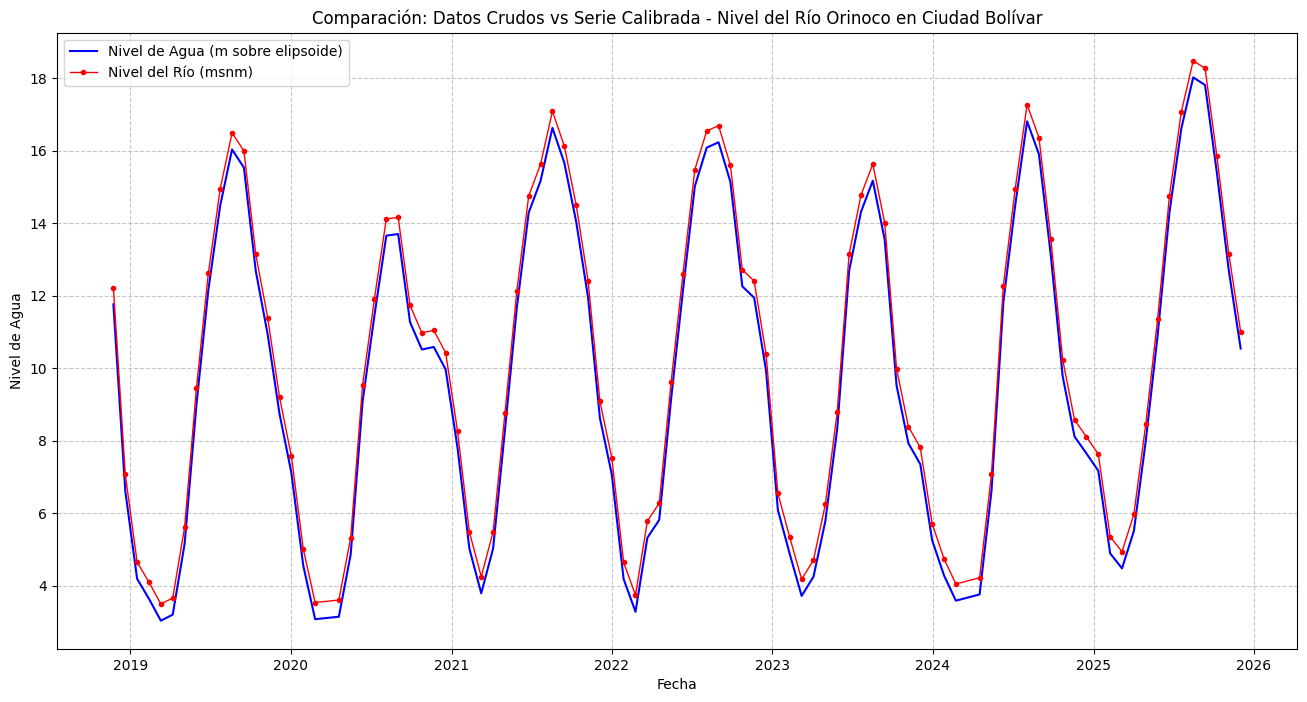

In [9]:
# Graficamos nuestra serie calibrada vs. la serie original
plt.figure(figsize=(16, 8))

# Primera serie (datos crudos)
plt.plot(df_ciudad_bolivar['datetime'], df_ciudad_bolivar['wse'], 'b-', label='Nivel de Agua (m sobre elipsoide)')

# Segunda serie (datos calibrados)  
plt.plot(df_ciudad_bolivar_desfase['datetime'], df_ciudad_bolivar_desfase['wse'], 'ro-', linewidth=1, markersize=3, label='Nivel del Río (msnm)')

plt.title('Comparación: Datos Crudos vs Serie Calibrada - Nivel del Río Orinoco en Ciudad Bolívar')
plt.ylabel('Nivel de Agua')
plt.xlabel('Fecha')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


## Conclusiones

Las limitaciones de este método son:

1) No considera factores locales como lo pueden ser las condiciones geográficas o estacionales de la zona, las cuales pueden ser determinantes en el comportamiento hidrológico y explicarían no solo el desfase, sino también la evolución temporal del mismo.
2) El reajuste depende únicamente del desfase existente. No es bueno para predecir, sino para aproximar, ya que, por lo mencionado en el punto anterior, símplemente es una inferencia.

Se recomienda usarlo para distancias cortas.